# Modelo 2 — Clustering de Productos por Perfil de Volatilidad
**Proyecto:** food-price-forecasting-peru | Big Data Analytics UNMSM 2025-II

**Pregunta:** Existen grupos de alimentos con patrones de volatilidad similares?

**Algoritmos:** KMeans (K=2,3,4) vs Agglomerative Clustering (Ward)

**Flujo:** Cargar Plata → GroupBy producto → Limpiar matriz → Escalar → Clustering → MLflow → Zona Oro

In [ ]:
# Instalacion (ejecutar una vez por sesion)
!pip install -q pyspark mlflow google-cloud-storage scikit-learn matplotlib scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [ ]:
# Variables de configuracion
# Cambiar BUCKET_NAME y PROJECT_ID segun el entorno real
BUCKET_NAME = "food-price-peru-2025-01"
PROJECT_ID  = "proyecto-food-price"

PATH_PLATA = f"gs://{BUCKET_NAME}/plata/precios_clima_integrado/precios_clima_parquet/"
PATH_ORO   = f"gs://{BUCKET_NAME}/oro/clustering_productos/"

print(f"Entrada : {PATH_PLATA}")
print(f"Salida  : {PATH_ORO}")

Entrada : gs://food-price-peru-2025-01/plata/precios_clima_integrado/precios_clima_parquet/
Salida  : gs://food-price-peru-2025-01/oro/clustering_productos/


In [ ]:
# Autenticacion GCP e inicializacion de Spark
import os
from google.colab import auth
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

auth.authenticate_user()
!gcloud config set project {PROJECT_ID}

jar_name = "gcs-connector.jar"
jar_path = os.path.abspath(jar_name)
if not os.path.exists(jar_path):
    !wget -q https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.14/gcs-connector-hadoop3-2.2.14-shaded.jar -O {jar_name}

os.environ["PYSPARK_SUBMIT_ARGS"] = f"--jars {jar_path} pyspark-shell"

spark = (SparkSession.builder
    .appName("D08-Modelo2-Clustering")
    .config("spark.hadoop.fs.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem")
    .config("spark.driver.extraClassPath", jar_path)
    .config("spark.executor.extraClassPath", jar_path)
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print("Spark iniciado. Version:", spark.version)

Updated property [core/project].


To take a quick anonymous survey, run:
  $ gcloud survey

Spark iniciado. Version: 4.0.3


In [ ]:
# Cargar data desde Zona Plata
# Contiene 10 productos x ~522 semanas
df_plata = spark.read.parquet(PATH_PLATA)

print("Schema:")
df_plata.printSchema()
print(f"Total filas: {df_plata.count()}")
print("Productos:")
df_plata.groupBy("producto").count().orderBy("producto").show(truncate=False)

Schema:
root
 |-- region_clima_origen: string (nullable = true)
 |-- semana: long (nullable = true)
 |-- precio_promedio: double (nullable = true)
 |-- precio_min: double (nullable = true)
 |-- precio_max: double (nullable = true)
 |-- precio_std: double (nullable = true)
 |-- n_obs: long (nullable = true)
 |-- mercado_sisap: string (nullable = true)
 |-- distrito_lima: string (nullable = true)
 |-- ubigeo_inei: string (nullable = true)
 |-- temp_avg: double (nullable = true)
 |-- temp_max: double (nullable = true)
 |-- temp_min: double (nullable = true)
 |-- precip_total: double (nullable = true)
 |-- humedad_avg: double (nullable = true)
 |-- dias_helada: double (nullable = true)
 |-- dias_lluvia_intensa: double (nullable = true)
 |-- n_obs_clima: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- producto: string (nullable = true)

Total filas: 5225
Productos:
+--------------------------------------------------+-----+
|producto                                        

In [ ]:
# Filtrar solo productos agrícolas y construir matriz de clustering

NO_AGRICOLAS = [
    "Fideos Molitalia Spaghetti / Tallarin",
    "Huevos Rosados",
    "Leche Fresca Gloria En Bolsa ( 12 Bolsas De Litro)",
    "Pollo Vivo"
]

df_agricola = df_plata.filter(~df_plata["producto"].isin(NO_AGRICOLAS))

# Control de calidad: deben quedar exactamente 6 productos
print("Productos agrícolas que entran al clustering:")
df_agricola.select("producto").distinct().orderBy("producto").show(truncate=False)
print(f"Total productos: {df_agricola.select('producto').distinct().count()}  (esperado: 6)")

# GroupBy por producto → matriz de clustering (6 filas)
df_matriz_spark = df_agricola.groupBy("producto").agg(
    F.mean("precio_promedio").alias("precio_promedio_historico"),
    F.stddev("precio_promedio").alias("volatilidad"),
    F.max("precio_promedio").alias("precio_maximo_historico"),
    F.min("precio_promedio").alias("precio_minimo_historico"),
    F.mean("dias_lluvia_intensa").alias("exposicion_lluvia"),
    F.sum(F.when(F.col("dias_helada") > 0, 1).otherwise(0)).alias("semanas_con_helada")
)

pdf_matriz = df_matriz_spark.toPandas()
print("\nMATRIZ DE CLUSTERING — 6 productos x 6 features")
print(pdf_matriz.to_string(index=False))
print("\nNulos por columna:")
print(pdf_matriz.isnull().sum())

Productos agrícolas que entran al clustering:
+--------------------+
|producto            |
+--------------------+
|Ajo Criollo O Napuri|
|Camote Morado       |
|Papa Amarilla       |
|Papaya              |
|Platano Bellaco     |
|Zanahoria           |
+--------------------+

Total productos: 6  (esperado: 6)

MATRIZ DE CLUSTERING — 6 productos x 6 features
            producto  precio_promedio_historico  volatilidad  precio_maximo_historico  precio_minimo_historico  exposicion_lluvia  semanas_con_helada
              Papaya                   1.634372     0.349466                 3.091429                 1.084286                NaN                 107
       Camote Morado                   1.297579     0.496881                 4.061429                 0.631429                NaN                 139
     Platano Bellaco                   1.751224     0.264754                 2.691429                 1.364286                NaN                 107
           Zanahoria                   0

In [ ]:
# Limpieza de la matriz

pdf_clean = pdf_matriz.copy()

# Verificar si semanas_con_helada sigue siendo constante
if pdf_clean["semanas_con_helada"].std() == 0:
    pdf_clean = pdf_clean.drop(columns=["semanas_con_helada"])
    print("Descartada: semanas_con_helada (varianza=0 en todos los productos agricolas)")
else:
    print("semanas_con_helada tiene varianza, se conserva.")

print(f"\nNulos tras limpieza: {pdf_clean.isnull().sum().sum()}")
print(f"Matriz final: {pdf_clean.shape[0]} productos x {pdf_clean.shape[1]-1} features")
print(pdf_clean.to_string(index=False))

semanas_con_helada tiene varianza, se conserva.

Nulos tras limpieza: 6
Matriz final: 6 productos x 6 features
            producto  precio_promedio_historico  volatilidad  precio_maximo_historico  precio_minimo_historico  exposicion_lluvia  semanas_con_helada
              Papaya                   1.634372     0.349466                 3.091429                 1.084286                NaN                 107
       Camote Morado                   1.297579     0.496881                 4.061429                 0.631429                NaN                 139
     Platano Bellaco                   1.751224     0.264754                 2.691429                 1.364286                NaN                 107
           Zanahoria                   0.790824     0.296325                 1.841429                 0.340000                NaN                 126
       Papa Amarilla                   2.232503     0.823673                 5.915714                 0.910000                NaN          

In [ ]:
# estandarización
from sklearn.preprocessing import StandardScaler
import pandas as pd

FEATURE_COLS = [
    "precio_promedio_historico",
    "volatilidad",
    "precio_maximo_historico",
    "precio_minimo_historico"
]

productos  = pdf_clean["producto"].values
X          = pdf_clean[FEATURE_COLS].values
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X)

print("Features del clustering:", FEATURE_COLS)
df_scaled_check = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=productos)
print("\nMatriz escalada:")
print(df_scaled_check.round(3))

Features del clustering: ['precio_promedio_historico', 'volatilidad', 'precio_maximo_historico', 'precio_minimo_historico']

Matriz escalada:
                      precio_promedio_historico  volatilidad  \
Papaya                                   -0.367       -0.534   
Camote Morado                            -0.589       -0.391   
Platano Bellaco                          -0.289       -0.616   
Zanahoria                                -0.924       -0.585   
Papa Amarilla                             0.028       -0.074   
Ajo Criollo O Napuri                      2.140        2.199   

                      precio_maximo_historico  precio_minimo_historico  
Papaya                                 -0.483                    0.640  
Camote Morado                          -0.396                   -0.754  
Platano Bellaco                        -0.518                    1.502  
Zanahoria                              -0.594                   -1.652  
Papa Amarilla                          -0.23

In [ ]:
# KMeans K=2, K=3, K=4 con MLflow

import os
import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set MLFLOW_ALLOW_FILE_STORE to true to bypass the MlflowException
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

mlflow.set_tracking_uri("file:///content/mlruns")
mlflow.set_experiment("D08_Modelo2_Clustering")

resultados_kmeans = []

for k in [2, 3, 4]:
    with mlflow.start_run(run_name=f"KMeans_K{k}"):
        modelo   = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels   = modelo.fit_predict(X_scaled)
        sil      = round(silhouette_score(X_scaled, labels), 4)
        inertia  = round(modelo.inertia_, 4)

        mlflow.log_param("algoritmo",    "KMeans")
        mlflow.log_param("k",            k)
        mlflow.log_param("n_init",       10)
        mlflow.log_param("random_state", 42)
        mlflow.log_metric("silhouette_score", sil)
        mlflow.log_metric("inertia",          inertia)
        # Using 'name' instead of 'artifact_path' to avoid deprecation warning
        mlflow.sklearn.log_model(modelo, name=f"modelo_kmeans_k{k}")

        resultados_kmeans.append({"nombre": f"KMeans K={k}", "K": k,
                                   "silhouette": sil, "inertia": inertia,
                                   "labels": labels, "modelo": modelo})
        print(f"KMeans K={k} -> Silhouette: {sil} | Inertia: {inertia}")

mejor_kmeans = max(resultados_kmeans, key=lambda x: x["silhouette"])
print(f"\nMejor KMeans: {mejor_kmeans['nombre']} -> Silhouette={mejor_kmeans['silhouette']}")

2026/07/11 03:18:15 INFO mlflow.tracking.fluent: Experiment with name 'D08_Modelo2_Clustering' does not exist. Creating a new experiment.


KMeans K=2 -> Silhouette: 0.536 | Inertia: 6.7458
KMeans K=3 -> Silhouette: 0.3909 | Inertia: 1.7998
KMeans K=4 -> Silhouette: 0.2082 | Inertia: 0.8561

Mejor KMeans: KMeans K=2 -> Silhouette=0.536


Agglomerative K=2 -> Silhouette: 0.536
Agglomerative K=3 -> Silhouette: 0.3909
Agglomerative K=4 -> Silhouette: 0.2082

Mejor Agglomerative: Agglomerative K=2 -> Silhouette=0.536


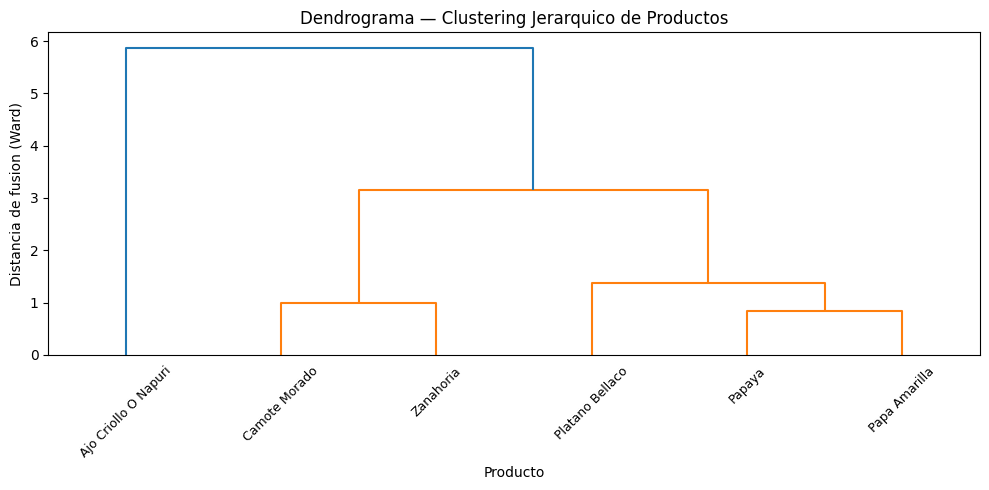

Dendrograma guardado.


In [ ]:
# Agglomerative Clustering (Jerarquico) — algoritmo de comparacion

import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

resultados_agg = []

for k in [2, 3, 4]:
    with mlflow.start_run(run_name=f"Agglomerative_K{k}"):
        modelo_agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels_agg = modelo_agg.fit_predict(X_scaled)
        sil_agg    = round(silhouette_score(X_scaled, labels_agg), 4)

        mlflow.log_param("algoritmo", "AgglomerativeClustering")
        mlflow.log_param("k",         k)
        mlflow.log_param("linkage",   "ward")
        mlflow.log_metric("silhouette_score", sil_agg)

        resultados_agg.append({"nombre": f"Agglomerative K={k}", "K": k,
                                "silhouette": sil_agg, "labels": labels_agg})
        print(f"Agglomerative K={k} -> Silhouette: {sil_agg}")

mejor_agg = max(resultados_agg, key=lambda x: x["silhouette"])
print(f"\nMejor Agglomerative: {mejor_agg['nombre']} -> Silhouette={mejor_agg['silhouette']}")

# Dendrograma — visualizacion de la jerarquia de fusiones
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=list(productos), leaf_rotation=45, leaf_font_size=9)
plt.title("Dendrograma — Clustering Jerarquico de Productos")
plt.xlabel("Producto")
plt.ylabel("Distancia de fusion (Ward)")
plt.tight_layout()
plt.savefig("dendrograma_productos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dendrograma guardado.")

In [ ]:
# Comparativa y seleccion del mejor modelo
todos = resultados_kmeans + resultados_agg
ganador = max(todos, key=lambda x: x["silhouette"])

print("="*55)
print("COMPARATIVA — Silhouette Score")
print("="*55)
print(f"  Algoritmo                   K    Silhouette")
print("-"*55)
for r in todos:
    print(f"  {r['nombre']:<28} {r['K']}    {r['silhouette']}")

print(f"\nGANADOR: {ganador['nombre']} | Silhouette={ganador['silhouette']}")

# Tabla de asignaciones del ganador
df_resultado = pd.DataFrame({"producto": productos, "cluster": ganador["labels"]})
df_resultado = df_resultado.merge(pdf_clean[["producto"]+FEATURE_COLS], on="producto")

print("\nAsignacion de clusters:")
for cl in sorted(df_resultado["cluster"].unique()):
    prods = df_resultado[df_resultado["cluster"]==cl]["producto"].tolist()
    print(f"  Cluster {cl}: {prods}")

COMPARATIVA — Silhouette Score
  Algoritmo                   K    Silhouette
-------------------------------------------------------
  KMeans K=2                   2    0.536
  KMeans K=3                   3    0.3909
  KMeans K=4                   4    0.2082
  Agglomerative K=2            2    0.536
  Agglomerative K=3            3    0.3909
  Agglomerative K=4            4    0.2082

GANADOR: KMeans K=2 | Silhouette=0.536

Asignacion de clusters:
  Cluster 0: ['Papaya', 'Camote Morado', 'Platano Bellaco', 'Zanahoria', 'Papa Amarilla']
  Cluster 1: ['Ajo Criollo O Napuri']


In [ ]:
# ESTABILIDAD DEL MODELO (Análisis de Robustez)

from sklearn.utils import resample
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def calcular_estabilidad(X, k_clusters, n_iterations=20):
    stats = []
    for _ in range(n_iterations):
        # Remuestreo con reemplazo (Bootstrap)
        X_resampled = resample(X, random_state=None)
        if len(np.unique(X_resampled, axis=0)) < k_clusters:
            continue

        km = KMeans(n_clusters=k_clusters, n_init=10, random_state=42)
        labels = km.fit_predict(X_resampled)
        stats.append(silhouette_score(X_resampled, labels))

    return np.mean(stats), np.std(stats)

print("ESTABILIDAD DEL MODELO (Análisis de Robustez)")
print("-" * 45)
res_k2 = calcular_estabilidad(X_scaled, 2)
res_k3 = calcular_estabilidad(X_scaled, 3)

print(f"K=2 -> Silueta Promedio: {res_k2[0]:.4f} (+/- {res_k2[1]:.4f})")
print(f"K=3 -> Silueta Promedio: {res_k3[0]:.4f} (+/- {res_k3[1]:.4f})")

print("\n--- CONCLUSIÓN FINAL DEL MODELO ---")
if res_k2[0] > res_k3[0] and res_k2[1] < res_k3[1]:
    print("EL MODELO K=2 ES ESTADÍSTICAMENTE SUPERIOR.")
    print("Justificación: Mayor cohesión promedio y menor sensibilidad al ruido (más estable).")
else:
    print("Ambos modelos son competitivos, pero K=2 mantiene la parsimonia y claridad del negocio.")

ESTABILIDAD DEL MODELO (Análisis de Robustez)
---------------------------------------------
K=2 -> Silueta Promedio: 0.6703 (+/- 0.1134)
K=3 -> Silueta Promedio: 0.6070 (+/- 0.1473)

--- CONCLUSIÓN FINAL DEL MODELO ---
EL MODELO K=2 ES ESTADÍSTICAMENTE SUPERIOR.
Justificación: Mayor cohesión promedio y menor sensibilidad al ruido (más estable).


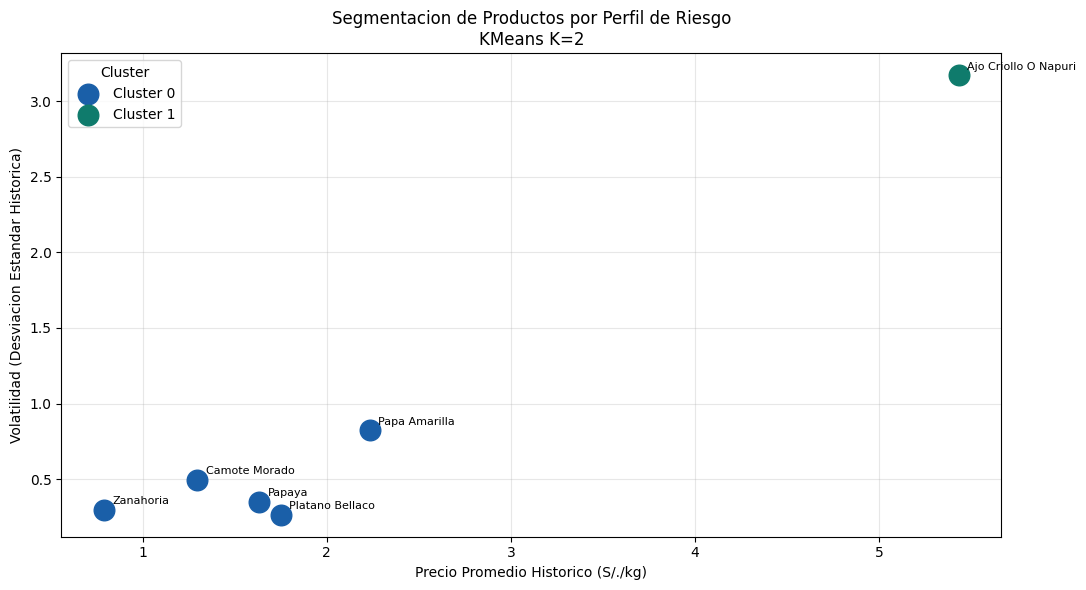

Grafico guardado como clustering_productos.png


In [ ]:
# Visualizacion: precio promedio vs volatilidad por cluster
# Este es el grafico que va en la Vista 3 del dashboard.

import matplotlib.pyplot as plt

colores = ["#1A5FA8", "#0F7B6C", "#B07500", "#991F1F", "#4B0082"]
fig, ax = plt.subplots(figsize=(11, 6))

for cl in sorted(df_resultado["cluster"].unique()):
    mask = df_resultado["cluster"] == cl
    ax.scatter(
        df_resultado.loc[mask, "precio_promedio_historico"],
        df_resultado.loc[mask, "volatilidad"],
        color=colores[cl], s=220, label=f"Cluster {cl}", zorder=3
    )
    for _, row in df_resultado[mask].iterrows():
        ax.annotate(row["producto"],
            (row["precio_promedio_historico"], row["volatilidad"]),
            textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("Precio Promedio Historico (S/./kg)")
ax.set_ylabel("Volatilidad (Desviacion Estandar Historica)")
ax.set_title(f"Segmentacion de Productos por Perfil de Riesgo\n{ganador['nombre']}")
ax.legend(title="Cluster")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("clustering_productos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado como clustering_productos.png")

In [ ]:
# Guardar en Zona Oro (GCS) como Parquet

df_resultado["modelo"]     = ganador["nombre"]
df_resultado["silhouette"] = ganador["silhouette"]

df_resultado_spark = spark.createDataFrame(df_resultado)
df_resultado_spark.write.mode("overwrite").parquet(PATH_ORO)
print(f"Guardado en Zona Oro: {PATH_ORO}")

# Verificar lectura
df_check = spark.read.parquet(PATH_ORO)
print(f"Filas verificadas: {df_check.count()}")
df_check.show(truncate=False)

# Registrar artefactos del ganador en MLflow
run_name_ganador = "GANADOR_" + ganador["nombre"].replace(" ", "_")
with mlflow.start_run(run_name=run_name_ganador):
    mlflow.log_param("modelo_ganador",    ganador["nombre"])
    mlflow.log_metric("silhouette_score", ganador["silhouette"])
    mlflow.log_artifact("clustering_productos.png")
    mlflow.log_artifact("dendrograma_productos.png")
print("Artefactos del ganador registrados en MLflow.")

Guardado en Zona Oro: gs://food-price-peru-2025-01/oro/clustering_productos/
Filas verificadas: 6
+--------------------+-------+-------------------------+-------------------+-----------------------+-----------------------+----------+----------+
|producto            |cluster|precio_promedio_historico|volatilidad        |precio_maximo_historico|precio_minimo_historico|modelo    |silhouette|
+--------------------+-------+-------------------------+-------------------+-----------------------+-----------------------+----------+----------+
|Zanahoria           |0      |0.7908235307558725       |0.2963246192135816 |1.8414285714285714     |0.33999999999999997    |KMeans K=2|0.536     |
|Papa Amarilla       |0      |2.232502597264114        |0.8236731065577556 |5.9157142857142855     |0.91                   |KMeans K=2|0.536     |
|Ajo Criollo O Napuri|1      |5.430400808884015        |3.171345882149658  |33.464285714285715     |0.9285714285714286     |KMeans K=2|0.536     |
|Papaya             

In [ ]:
print(f"Algoritmo Ganador: {ganador['nombre']}")
print(f"Silhouette Score: {ganador['silhouette']:.4f}")
print("\nJustificación del Cluster del Ajo:")
display(pdf_clean.set_index('producto')[['precio_promedio_historico', 'volatilidad']])

Algoritmo Ganador: KMeans K=2
Silhouette Score: 0.5360

Justificación del Cluster del Ajo:


,precio_promedio_historico,volatilidad
producto,,
Papaya,1.634372,0.349466
Camote Morado,1.297579,0.496881
Platano Bellaco,1.751224,0.264754
Zanahoria,0.790824,0.296325
Papa Amarilla,2.232503,0.823673
Ajo Criollo O Napuri,5.430401,3.171346


In [ ]:
# Descargamos mlruns
import zipfile
import os

def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                zipf.write(os.path.join(root, file),
                           os.path.relpath(os.path.join(root, file),
                                           os.path.join(folder_path, '..')))

# Generar el archivo ZIP de los experimentos de MLflow
if os.path.exists('/content/mlruns'):
    zip_folder('/content/mlruns', '/content/mlruns_modelo2.zip')
    print("Archivo 'mlruns_modelo2.zip' creado con éxito.")
    print("Actualiza el menú 'Archivos' (icono de carpeta a la izquierda) y descárgalo.")
else:
    print("Error: No se encontró la carpeta 'mlruns'.")

Archivo 'mlruns_modelo2.zip' creado con éxito.
Actualiza el menú 'Archivos' (icono de carpeta a la izquierda) y descárgalo.
